# Agricultural Futures Final Project

## Strategy Evaluation Notebook

This notebook assumes the data engineering work is already done.

Required prepared inputs:
- [corn_futures_data_builder.ipynb](./corn_futures_data_builder.ipynb)
- [wheat_futures_data_builder.ipynb](./wheat_futures_data_builder.ipynb) for the optional pairs section
- [mod13a2_ndvi_data_builder.ipynb](./mod13a2_ndvi_data_builder.ipynb)

The purpose of this notebook is only to:
- load prepared CSV caches
- build course-style strategy signals
- compare Sharpe ratios and other summary metrics
- test simple combinations of strategy sleeves


In [17]:
from pathlib import Path
from itertools import product
import os
import warnings

def locate_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data_ag_futures').exists() and (candidate / 'notebooks_ag_futures').exists():
            return candidate
    raise FileNotFoundError('Could not locate a project root containing data_ag_futures and notebooks_ag_futures.')

PROJECT_ROOT = locate_project_root()
NOTEBOOKS_ROOT = PROJECT_ROOT / 'notebooks_ag_futures'
os.environ.setdefault('MPLCONFIGDIR', str(NOTEBOOKS_ROOT / '.mplconfig'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore', category=FutureWarning)
DATA_ROOT = PROJECT_ROOT / 'data_ag_futures'
PROCESSED_DIR = DATA_ROOT / 'processed'

CORN_CACHE_PATH = PROCESSED_DIR / 'corn_continuous_back_adjusted.csv'
WHEAT_CACHE_PATH = PROCESSED_DIR / 'wheat_continuous_back_adjusted.csv'
NDVI_LEVEL_CACHE_PATH = PROCESSED_DIR / 'mod13a2_ndvi_level_series.csv'
NDVI_DAILY_CACHE_PATH = PROCESSED_DIR / 'mod13a2_ndvi_daily_series.csv'
PAIRS_CACHE_PATH = PROCESSED_DIR / 'corn_wheat_pairs_panel.csv'

MA_PAIRS = [(10, 30), (30, 100), (80, 160)]
PRIMARY_PAIR = (30, 100)
RUN_WHEAT_PAIRS_ANALYSIS = True
COMBINATION_GRID_STEP = 0.1
MAX_STRATEGIES_IN_COMBO = 4
SAVE_STRATEGY_OUTPUTS = False


def annualized_sharpe(returns, periods=252):
    series = pd.Series(returns).dropna()
    if series.empty or series.std() == 0:
        return np.nan
    return np.sqrt(periods) * series.mean() / series.std()


def max_drawdown(returns):
    series = pd.Series(returns).fillna(0.0)
    wealth = (1.0 + series).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return drawdown.min()


def summarize_strategy(name, returns, signal=None):
    series = pd.Series(returns).dropna()
    if series.empty:
        cum_return = np.nan
        ann_vol = np.nan
        mdd = np.nan
    else:
        cum_return = (1.0 + series).prod() - 1.0
        ann_vol = series.std() * np.sqrt(252)
        mdd = max_drawdown(series)
    summary = {
        'strategy': name,
        'obs': int(series.shape[0]),
        'cum_return': cum_return,
        'ann_sharpe': annualized_sharpe(series),
        'ann_vol': ann_vol,
        'max_drawdown': mdd,
    }
    if signal is not None:
        sig = pd.Series(signal).dropna()
        summary['active_share'] = sig.abs().mean() if not sig.empty else np.nan
    return summary


def require_file(path, label):
    if not path.exists():
        raise FileNotFoundError(f'{label} not found at {path}. Build it in the corresponding data-builder notebook first.')
    return path


def load_futures_cache(path, label):
    require_file(path, label)
    frame = pd.read_csv(path, parse_dates=['Date']).set_index('Date').sort_index()
    required = ['Open', 'High', 'Low', 'Close', 'Adj_Close_Futures', 'futures_ret']
    missing = [col for col in required if col not in frame.columns]
    if missing:
        raise ValueError(f'{label} cache is missing required columns: {missing}')
    return frame


def load_ndvi_caches(level_path, daily_path):
    require_file(level_path, 'NDVI level cache')
    require_file(daily_path, 'NDVI daily cache')
    ndvi_level = pd.read_csv(level_path, parse_dates=['date']).set_index('date').sort_index()
    ndvi_daily = pd.read_csv(daily_path, parse_dates=['Date']).set_index('Date').sort_index()
    required_daily = ['ndvi', 'ndvi_z', 'ndvi_regime']
    missing = [col for col in required_daily if col not in ndvi_daily.columns]
    if missing:
        raise ValueError(f'NDVI daily cache is missing required columns: {missing}')
    level_overlay = ndvi_daily.reindex(ndvi_level.index)[['ndvi_roll_mean', 'ndvi_roll_std', 'ndvi_z', 'ndvi_regime']]
    ndvi_level = ndvi_level.join(level_overlay, how='left')
    return ndvi_level, ndvi_daily


def add_ma_signals(frame, pairs):
    data = frame.copy()
    daily_pct = data['Adj_Close_Futures'].pct_change()
    for short_window, long_window in pairs:
        short_col = f'ma{short_window}'
        long_col = f'ma{long_window}'
        signal_col = f'signal_{short_window}_{long_window}'
        strat_col = f'strategy_ret_{short_window}_{long_window}'
        data[short_col] = daily_pct.rolling(short_window).mean()
        data[long_col] = daily_pct.rolling(long_window).mean()
        signal = pd.Series(
            np.where(data[short_col] > data[long_col], 1.0, -1.0),
            index=data.index,
            dtype='float64',
        )
        signal[data[short_col].isna() | data[long_col].isna()] = np.nan
        data[signal_col] = signal
        data[strat_col] = data[signal_col].shift(1) * data['futures_ret']
    return data


def apply_ndvi_overlay(frame, primary_pair):
    data = frame.copy()
    signal_col = f'signal_{primary_pair[0]}_{primary_pair[1]}'
    data['overlay_signal'] = np.where(
        data[signal_col].isna(),
        np.nan,
        np.where(
            data['ndvi_regime'] == data[signal_col],
            data[signal_col],
            np.where(data['ndvi_regime'] == 0.0, 0.5 * data[signal_col], 0.0),
        ),
    )
    data['overlay_ret'] = data['overlay_signal'].shift(1) * data['futures_ret']
    return data


def run_countertrend_strategy(frame, p=2.2, avg_range_window=20, prior_high_window=20):
    data = frame[['Open', 'High', 'Low', 'Close', 'Adj_Close_Futures', 'futures_ret']].copy()
    data['DayRange'] = data['High'] - data['Low']
    data['Av20R'] = data['DayRange'].shift(1).rolling(avg_range_window).mean()
    data['PrvHiWRoll'] = data['High'].shift(1).rolling(prior_high_window).max()
    data['HitLevel'] = data['PrvHiWRoll'] - (p * data['Av20R'])
    data['Hit?'] = data['Low'] < data['HitLevel']
    data['HitAt'] = np.where(data['Open'] < data['HitLevel'], data['Open'], data['HitLevel'])
    data['HitAt'] = np.where(data['Hit?'], data['HitAt'], np.nan)
    data['ExitPr'] = data['Close']
    data['strategy_return'] = np.where(data['Hit?'], (data['ExitPr'] - data['HitAt']) / data['HitAt'], 0.0)
    data['signal'] = np.where(data['Hit?'], 1.0, 0.0)
    return data


def run_vol_regime_strategy(frame, vol_window=20, z_window=250, neutral_low=0.0, neutral_high=0.5):
    data = frame[['futures_ret']].copy()
    data['vol20'] = data['futures_ret'].rolling(vol_window).std()
    mean_ref = data['vol20'].shift(1).rolling(z_window).mean()
    std_ref = data['vol20'].shift(1).rolling(z_window).std()
    data['zvol20'] = (data['vol20'] - mean_ref) / std_ref
    data['signal'] = np.where((data['zvol20'] < neutral_low) | (data['zvol20'] > neutral_high), 1.0, -1.0)
    data.loc[data['zvol20'].isna(), 'signal'] = np.nan
    data['strategy_return'] = data['signal'].shift(1) * data['futures_ret']
    return data


def dickey_fuller_diagnostics(spread):
    series = pd.Series(spread).dropna()
    test = pd.DataFrame({'spread': series})
    test['delta_spread'] = test['spread'].diff()
    test['lag_spread'] = test['spread'].shift(1)
    test = test.dropna()
    model = sm.OLS(test['delta_spread'], sm.add_constant(test['lag_spread'])).fit()
    adf_stat, pvalue, n_lags, n_obs, critical_values, _ = adfuller(series, regression='c', autolag='AIC')
    return {
        'df_tstat_regression': float(model.tvalues['lag_spread']),
        'adf_stat': float(adf_stat),
        'pvalue': float(pvalue),
        'critical_10pct': critical_values['10%'],
        'critical_5pct': critical_values['5%'],
        'critical_1pct': critical_values['1%'],
        'observations': int(n_obs),
    }


def build_pairs_panel(corn_frame, wheat_frame, horizons=(5, 10, 20)):
    pair = pd.DataFrame({
        'corn': corn_frame['Adj_Close_Futures'],
        'wheat': wheat_frame['Adj_Close_Futures'],
    }).dropna().copy()
    pair['spread_price'] = pair['corn'] - pair['wheat']
    pair['ret1CORN'] = pair['corn'].pct_change()
    pair['ret1WHEAT'] = pair['wheat'].pct_change()
    for horizon in horizons:
        for label in ['CORN', 'WHEAT']:
            price_col = 'corn' if label == 'CORN' else 'wheat'
            pair[f'{label}_ret{horizon}'] = pair[price_col].pct_change(horizon)
            pair[f'z{label}{horizon}'] = (
                (pair[f'{label}_ret{horizon}'] - pair[f'{label}_ret{horizon}'].shift(1).rolling(60).mean())
                / pair[f'{label}_ret{horizon}'].shift(1).rolling(60).std()
            )
        pair[f'zdiff{horizon}'] = pair[f'zCORN{horizon}'] - pair[f'zWHEAT{horizon}']
    pair['vol20CORN'] = pair['ret1CORN'].rolling(20).std()
    pair['vol20WHEAT'] = pair['ret1WHEAT'].rolling(20).std()
    pair['invvolCORN'] = 1.0 / pair['vol20CORN']
    pair['invvolWHEAT'] = 1.0 / pair['vol20WHEAT']
    pair['sum_invvol'] = pair['invvolCORN'] + pair['invvolWHEAT']
    pair['wCORN'] = pair['invvolCORN'] / pair['sum_invvol']
    pair['wWHEAT'] = pair['invvolWHEAT'] / pair['sum_invvol']
    pair['future_spread_ret'] = pair['wCORN'] * pair['ret1CORN'].shift(-1) - pair['wWHEAT'] * pair['ret1WHEAT'].shift(-1)
    return pair


def run_pairs_position_strategy(spread_col, fret1, long_entry=-1.0, short_entry=1.0, long_cap=1.0, short_cap=-1.0, max_holding=5):
    age = 0
    ages = []
    positions = []
    current_position = 0
    for spread in spread_col:
        if current_position == 1 and (spread >= long_cap or age >= max_holding):
            current_position = 0
            age = 0
        elif current_position == -1 and (spread <= short_cap or age >= max_holding):
            current_position = 0
            age = 0
        if current_position == 0:
            if spread <= long_entry:
                current_position = 1
                age = 1
            elif spread >= short_entry:
                current_position = -1
                age = 1
        else:
            age += 1
        ages.append(age)
        positions.append(current_position)
    results = pd.DataFrame({'position': positions, 'age': ages}, index=pd.Index(spread_col.index))
    results['strategy_return'] = results['position'] * fret1
    return results


def build_weight_grid(n_assets, step=0.1):
    units = int(round(1.0 / step))
    combos = []
    for values in product(range(units + 1), repeat=n_assets):
        if sum(values) == units:
            combos.append(np.array(values, dtype=float) / units)
    return combos


def optimize_strategy_combo(returns_frame, top_n=4, step=0.1):
    summaries = []
    for col in returns_frame.columns:
        summaries.append(summarize_strategy(col, returns_frame[col]))
    summary_df = pd.DataFrame(summaries).set_index('strategy')
    ranked = summary_df.sort_values('ann_sharpe', ascending=False)
    candidate_names = ranked[ranked['ann_sharpe'] > 0].head(top_n).index.tolist()
    if len(candidate_names) < 2:
        return summary_df, None, None, candidate_names, None
    combo_frame = returns_frame[candidate_names].dropna()
    if combo_frame.empty:
        return summary_df, None, None, candidate_names, None
    best = None
    best_returns = None
    for weights in build_weight_grid(len(candidate_names), step=step):
        combined = combo_frame.mul(weights, axis=1).sum(axis=1)
        sharpe = annualized_sharpe(combined)
        drawdown = max_drawdown(combined)
        if np.isnan(sharpe):
            continue
        if best is None or sharpe > best['ann_sharpe'] or (np.isclose(sharpe, best['ann_sharpe']) and drawdown > best['max_drawdown']):
            best = {
                'weights': dict(zip(candidate_names, weights)),
                'ann_sharpe': sharpe,
                'cum_return': (1.0 + combined).prod() - 1.0,
                'ann_vol': combined.std() * np.sqrt(252),
                'max_drawdown': drawdown,
                'obs': int(combined.shape[0]),
            }
            best_returns = combined
    equal_weight_returns = combo_frame.mean(axis=1)
    return summary_df, best, best_returns, candidate_names, equal_weight_returns


In [18]:
corn = add_ma_signals(load_futures_cache(CORN_CACHE_PATH, 'corn futures cache'), MA_PAIRS)
ndvi_level, ndvi_daily = load_ndvi_caches(NDVI_LEVEL_CACHE_PATH, NDVI_DAILY_CACHE_PATH)
print(f'Corn cache range: {corn.index.min().date()} to {corn.index.max().date()}')
print(f'NDVI level range: {ndvi_level.index.min().date()} to {ndvi_level.index.max().date()}')
print(f'NDVI daily range: {ndvi_daily.index.min().date()} to {ndvi_daily.index.max().date()}')


Corn cache range: 2000-07-17 to 2026-04-30
NDVI level range: 2000-02-18 to 2026-04-07
NDVI daily range: 2000-02-18 to 2026-04-07


## Corn Baseline and NDVI Regime Overlay

This section compares buy-and-hold, the class trend rules, and the NDVI overlay on the primary `30/100` trend rule.


               obs  cum_return  ann_sharpe  ann_vol  max_drawdown  \
strategy                                                            
buy_and_hold  6451      1.6320      0.2776   0.3076       -0.6644   
ma_10_30      6421      2.7582      0.3231   0.3082       -0.5738   
ma_30_100     6351     -0.8379     -0.0780   0.3093       -0.9389   
ma_80_160     6291     -0.1554      0.1340   0.3103       -0.8763   

              active_share  
strategy                    
buy_and_hold           NaN  
ma_10_30               1.0  
ma_30_100              1.0  
ma_80_160              1.0  
NDVI overlay summary
                      obs  cum_return  ann_sharpe  ann_vol  max_drawdown  \
strategy                                                                   
buy_and_hold         6434      1.4893      0.2708   0.3080       -0.6644   
ma_30_100            6334     -0.8297     -0.0718   0.3096       -0.9389   
ma_30_100_plus_ndvi  6334      1.8663      0.3016   0.2162       -0.6469   

         

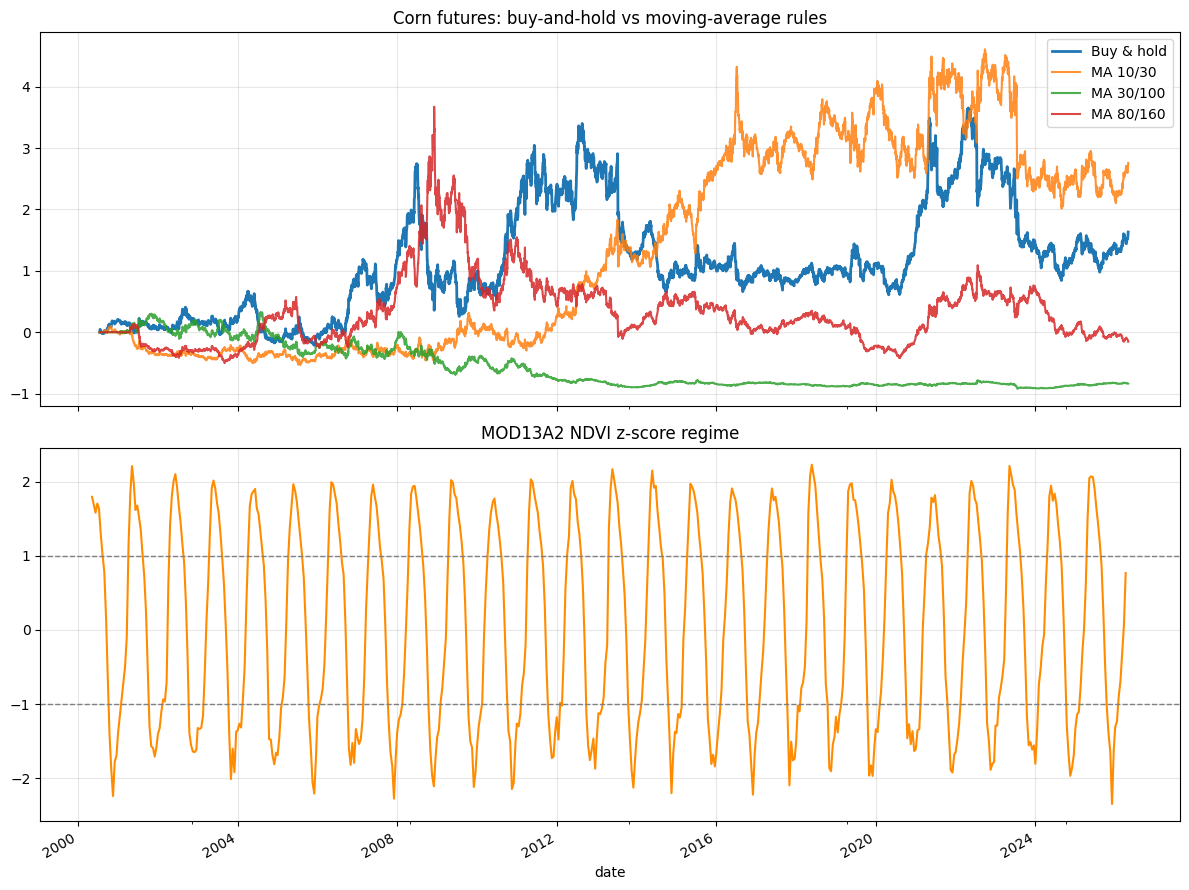

In [19]:
baseline_summaries = [summarize_strategy('buy_and_hold', corn['futures_ret'])]
for short_window, long_window in MA_PAIRS:
    strat_col = f'strategy_ret_{short_window}_{long_window}'
    signal_col = f'signal_{short_window}_{long_window}'
    baseline_summaries.append(
        summarize_strategy(
            f'ma_{short_window}_{long_window}',
            corn[strat_col],
            corn[signal_col],
        )
    )
baseline_summary = pd.DataFrame(baseline_summaries).set_index('strategy').round(4)
print(baseline_summary)

ndvi_overlay_analysis = corn.join(ndvi_daily[['ndvi', 'ndvi_z', 'ndvi_regime']], how='inner')
ndvi_overlay_analysis = apply_ndvi_overlay(ndvi_overlay_analysis, PRIMARY_PAIR)
if SAVE_STRATEGY_OUTPUTS:
    ndvi_overlay_analysis.to_csv(PROCESSED_DIR / 'corn_ndvi_overlay_panel.csv', index_label='Date')
ndvi_overlay_summary = pd.DataFrame([
    summarize_strategy('buy_and_hold', ndvi_overlay_analysis['futures_ret']),
    summarize_strategy('ma_30_100', ndvi_overlay_analysis['strategy_ret_30_100'], ndvi_overlay_analysis['signal_30_100']),
    summarize_strategy('ma_30_100_plus_ndvi', ndvi_overlay_analysis['overlay_ret'], ndvi_overlay_analysis['overlay_signal']),
]).set_index('strategy').round(4)
print('NDVI overlay summary')
print(ndvi_overlay_summary)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
((1 + corn['futures_ret'].fillna(0)).cumprod() - 1).plot(ax=axes[0], label='Buy & hold', linewidth=2)
for short_window, long_window in MA_PAIRS:
    strat_col = f'strategy_ret_{short_window}_{long_window}'
    label = f'MA {short_window}/{long_window}'
    ((1 + corn[strat_col].fillna(0)).cumprod() - 1).plot(ax=axes[0], label=label, alpha=0.85)
axes[0].set_title('Corn futures: buy-and-hold vs moving-average rules')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

ndvi_level['ndvi_z'].plot(ax=axes[1], color='darkorange', linewidth=1.5)
axes[1].axhline(-1.0, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('MOD13A2 NDVI z-score regime')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Additional Corn Strategies from the Course

This section ports the counter-trend bounce idea and the volatility-regime rule into the agricultural setting.


                     obs  cum_return  ann_sharpe  ann_vol  max_drawdown  \
strategy                                                                  
countertrend_p2_2   6452      0.0373      0.1068   0.1996       -0.7333   
vol_regime_shifted  6181     10.0235      0.4711   0.3108       -0.5660   

                    active_share  
strategy                          
countertrend_p2_2         0.6046  
vol_regime_shifted        1.0000  


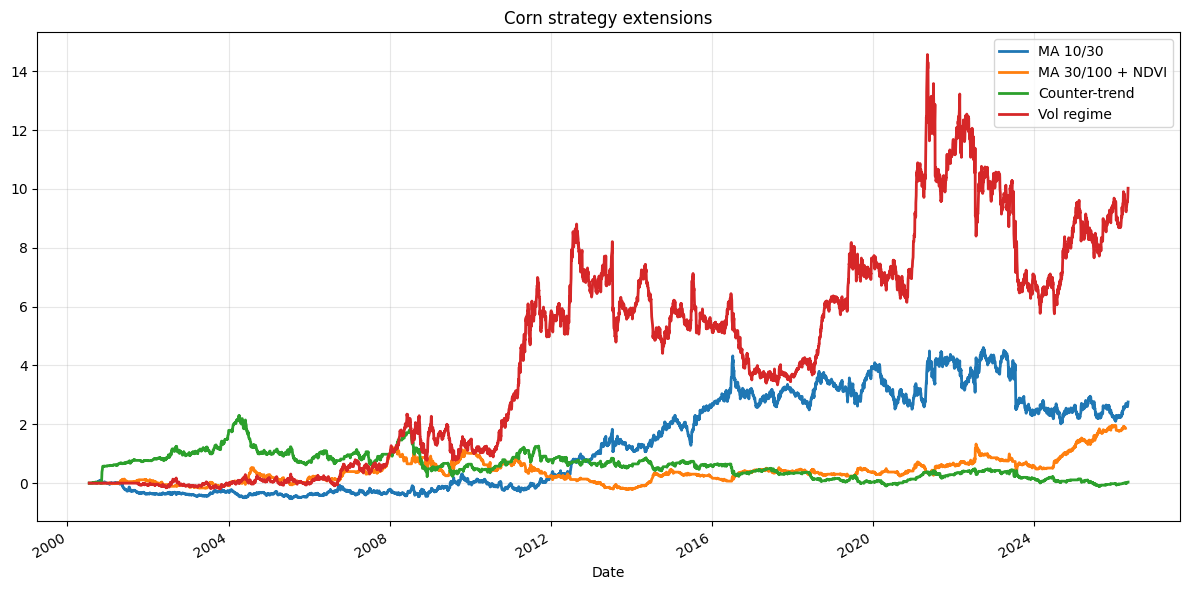

In [20]:
countertrend = run_countertrend_strategy(corn, p=2.2)
vol_regime = run_vol_regime_strategy(corn)

corn_extra_summary = pd.DataFrame([
    summarize_strategy('countertrend_p2_2', countertrend['strategy_return'], countertrend['signal']),
    summarize_strategy('vol_regime_shifted', vol_regime['strategy_return'], vol_regime['signal']),
]).set_index('strategy').round(4)
print(corn_extra_summary)

fig, ax = plt.subplots(figsize=(12, 6))
((1 + corn['strategy_ret_10_30'].fillna(0)).cumprod() - 1).plot(ax=ax, label='MA 10/30', linewidth=2)
((1 + ndvi_overlay_analysis['overlay_ret'].fillna(0)).cumprod() - 1).plot(ax=ax, label='MA 30/100 + NDVI', linewidth=2)
((1 + countertrend['strategy_return'].fillna(0)).cumprod() - 1).plot(ax=ax, label='Counter-trend', linewidth=2)
((1 + vol_regime['strategy_return'].fillna(0)).cumprod() - 1).plot(ax=ax, label='Vol regime', linewidth=2)
ax.set_title('Corn strategy extensions')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Optional Wheat and Corn-Wheat Pairs Study

This section runs only if the wheat cache has already been built.


Wheat cache range: 2000-07-17 to 2026-04-30
Corn-wheat spread stationarity diagnostics
{'df_tstat_regression': -4.465005101640795, 'adf_stat': -3.975195563718148, 'pvalue': 0.0015461113499091828, 'critical_10pct': np.float64(-2.5670099934630133), 'critical_5pct': np.float64(-2.861990867326618), 'critical_1pct': np.float64(-3.43137026198315), 'observations': 6412}
Pairs strategy summary
            obs  cum_return  ann_sharpe  ann_vol  max_drawdown  active_share
strategy                                                                    
pairs_5d   6415      0.0946      0.0905   0.1235       -0.4136        0.4882
pairs_10d  6415      0.0550      0.0784   0.1228       -0.4013        0.4737
pairs_20d  6415     -0.4835     -0.1459   0.1247       -0.6430        0.4842


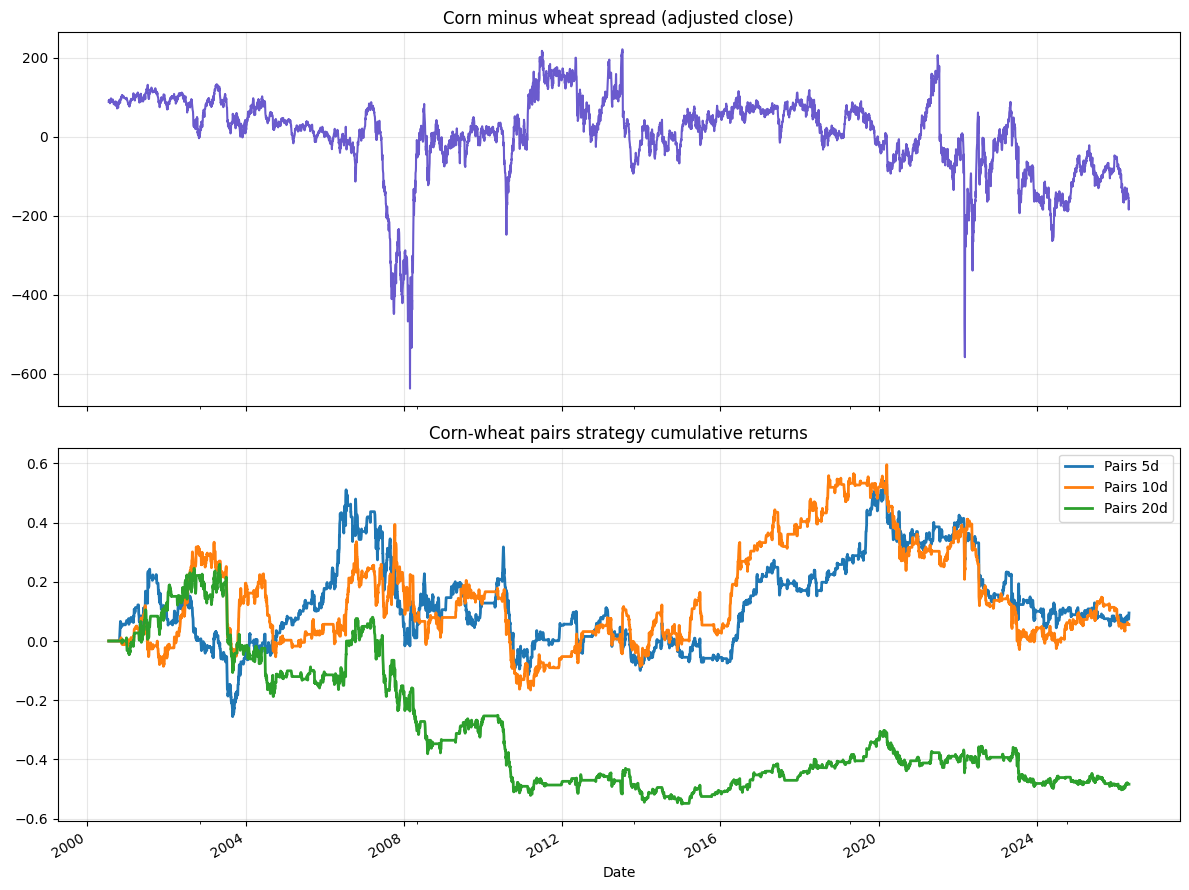

In [21]:
pairs_panel = pd.DataFrame()
pairs_strategy_summary = pd.DataFrame()
pairs_diagnostics = None

if RUN_WHEAT_PAIRS_ANALYSIS and WHEAT_CACHE_PATH.exists():
    wheat = add_ma_signals(load_futures_cache(WHEAT_CACHE_PATH, 'wheat futures cache'), MA_PAIRS)
    print(f'Wheat cache range: {wheat.index.min().date()} to {wheat.index.max().date()}')
    pairs_panel = build_pairs_panel(corn, wheat)
    if SAVE_STRATEGY_OUTPUTS:
        pairs_panel.to_csv(PAIRS_CACHE_PATH, index_label='Date')
    pairs_diagnostics = dickey_fuller_diagnostics(pairs_panel['spread_price'])
    print('Corn-wheat spread stationarity diagnostics')
    print(pairs_diagnostics)

    for horizon in [5, 10, 20]:
        result = run_pairs_position_strategy(pairs_panel[f'zdiff{horizon}'], pairs_panel['future_spread_ret'])
        pairs_panel[f'pairs_ret_{horizon}'] = result['strategy_return']
        pairs_panel[f'pairs_pos_{horizon}'] = result['position']
    pairs_strategy_summary = pd.DataFrame([
        summarize_strategy('pairs_5d', pairs_panel['pairs_ret_5'], pairs_panel['pairs_pos_5']),
        summarize_strategy('pairs_10d', pairs_panel['pairs_ret_10'], pairs_panel['pairs_pos_10']),
        summarize_strategy('pairs_20d', pairs_panel['pairs_ret_20'], pairs_panel['pairs_pos_20']),
    ]).set_index('strategy').round(4)
    print('Pairs strategy summary')
    print(pairs_strategy_summary)

    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    pairs_panel['spread_price'].plot(ax=axes[0], color='slateblue', linewidth=1.5)
    axes[0].set_title('Corn minus wheat spread (adjusted close)')
    axes[0].grid(True, alpha=0.3)
    ((1 + pairs_panel['pairs_ret_5'].fillna(0)).cumprod() - 1).plot(ax=axes[1], label='Pairs 5d', linewidth=2)
    ((1 + pairs_panel['pairs_ret_10'].fillna(0)).cumprod() - 1).plot(ax=axes[1], label='Pairs 10d', linewidth=2)
    ((1 + pairs_panel['pairs_ret_20'].fillna(0)).cumprod() - 1).plot(ax=axes[1], label='Pairs 20d', linewidth=2)
    axes[1].set_title('Corn-wheat pairs strategy cumulative returns')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print('Pairs analysis skipped because the wheat cache is missing or disabled.')


## Combine Strategy Return Streams

This section computes simple annualized Sharpe ratios and then performs a coarse weight search across the strongest sleeves.


All strategy return streams ranked by Sharpe
                      obs  cum_return  ann_sharpe  ann_vol  max_drawdown
strategy                                                                
vol_regime_shifted   6181     10.0235      0.4711   0.3108       -0.5660
ma_10_30             6421      2.7582      0.3231   0.3082       -0.5738
ma_30_100_plus_ndvi  6334      1.8663      0.3016   0.2162       -0.6469
ma_80_160            6291     -0.1554      0.1340   0.3103       -0.8763
countertrend_p2_2    6452      0.0373      0.1068   0.1996       -0.7333
pairs_ret_5          6415      0.0946      0.0905   0.1235       -0.4136
pairs_ret_10         6415      0.0550      0.0784   0.1228       -0.4013
ma_30_100            6351     -0.8379     -0.0780   0.3093       -0.9389
pairs_ret_20         6415     -0.4835     -0.1459   0.1247       -0.6430
Combo candidates
['vol_regime_shifted', 'ma_10_30', 'ma_30_100_plus_ndvi', 'ma_80_160']
Combination summary
                      obs  cum_return  ann_s

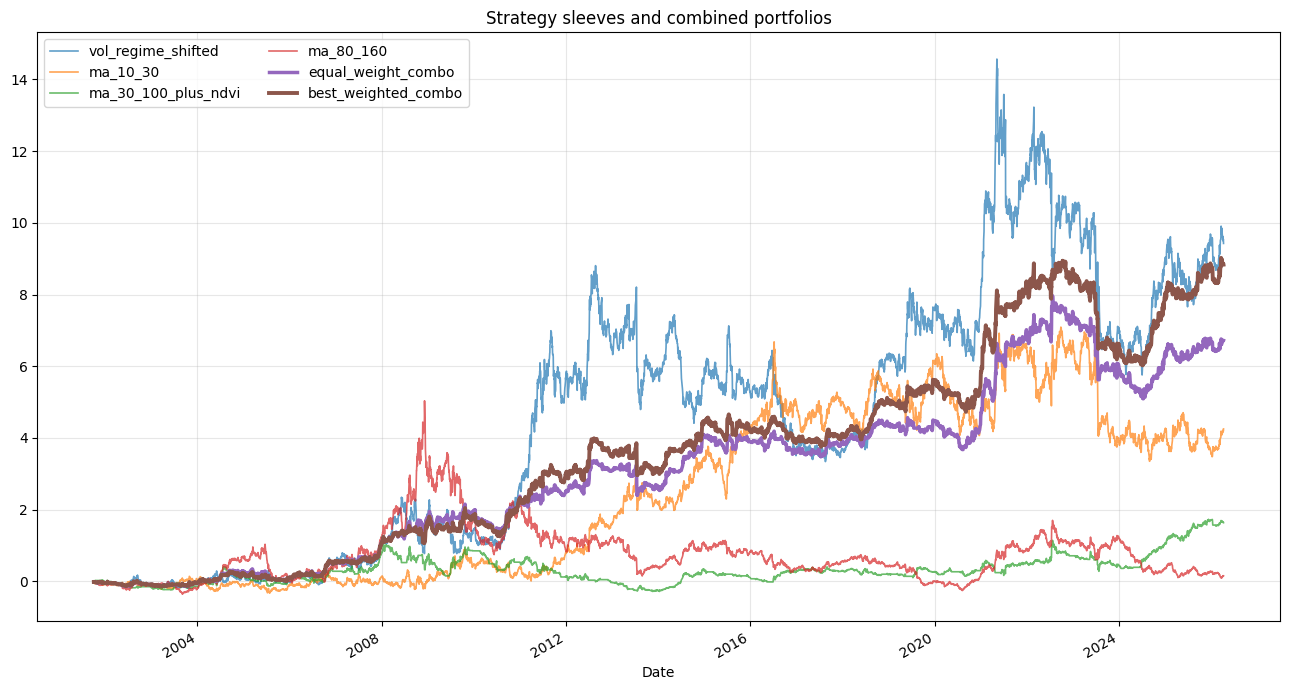

In [22]:
strategy_returns = pd.DataFrame(index=corn.index)
strategy_returns['ma_10_30'] = corn['strategy_ret_10_30']
strategy_returns['ma_30_100'] = corn['strategy_ret_30_100']
strategy_returns['ma_80_160'] = corn['strategy_ret_80_160']
strategy_returns['countertrend_p2_2'] = countertrend['strategy_return']
strategy_returns['vol_regime_shifted'] = vol_regime['strategy_return']
strategy_returns['ma_30_100_plus_ndvi'] = ndvi_overlay_analysis['overlay_ret']
if not pairs_panel.empty:
    strategy_returns = strategy_returns.join(pairs_panel[['pairs_ret_5', 'pairs_ret_10', 'pairs_ret_20']], how='left')

strategy_summary_all, best_combo, best_combo_returns, combo_candidates, equal_weight_returns = optimize_strategy_combo(
    strategy_returns,
    top_n=MAX_STRATEGIES_IN_COMBO,
    step=COMBINATION_GRID_STEP,
)
strategy_summary_all = strategy_summary_all.sort_values('ann_sharpe', ascending=False).round(4)
print('All strategy return streams ranked by Sharpe')
print(strategy_summary_all)
print('Combo candidates')
print(combo_candidates)

if best_combo is None:
    print('Not enough positive-Sharpe strategy streams were available to build a combination portfolio.')
else:
    combo_summary = pd.DataFrame([
        summarize_strategy('equal_weight_combo', equal_weight_returns),
        summarize_strategy('best_weighted_combo', best_combo_returns),
    ]).set_index('strategy').round(4)
    print('Combination summary')
    print(combo_summary)
    print('Best weights')
    print(best_combo['weights'])

    plot_frame = pd.DataFrame(index=best_combo_returns.index)
    for name in combo_candidates:
        plot_frame[name] = strategy_returns[name].reindex(best_combo_returns.index)
    plot_frame['equal_weight_combo'] = equal_weight_returns
    plot_frame['best_weighted_combo'] = best_combo_returns

    fig, ax = plt.subplots(figsize=(13, 7))
    for name in combo_candidates:
        ((1 + plot_frame[name].fillna(0)).cumprod() - 1).plot(ax=ax, linewidth=1.2, alpha=0.7, label=name)
    ((1 + plot_frame['equal_weight_combo'].fillna(0)).cumprod() - 1).plot(ax=ax, linewidth=2.5, label='equal_weight_combo')
    ((1 + plot_frame['best_weighted_combo'].fillna(0)).cumprod() - 1).plot(ax=ax, linewidth=2.8, label='best_weighted_combo')
    ax.set_title('Strategy sleeves and combined portfolios')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()


## Notes

- This notebook is now intentionally strategy-only. If a required CSV is missing, build it in the appropriate data-builder notebook first.
- The Sharpe ratio used throughout is the simple annualized mean-over-volatility version requested for this project, with no beta or benchmark subtraction.
- The pairs section is empirical rather than assumed: if the corn-wheat spread does not look convincing, treat those results as exploratory.
- The weighted-combination section is a coarse search, not a production optimizer.
